In [ ]:
!git clone "https://github.com/ProductPriceTrackerOrg/data-science.git"

Cloning into 'data-science'...
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (211/211), done.
remote: Compressing objects: 100% (176/176), done.
remote: Total 211 (delta 68), reused 93 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (211/211), 15.73 MiB | 4.20 MiB/s, done.
Resolving deltas: 100% (68/68), done.


## Import Libraries and Setup


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Define Custom Dataset Class
Description: Create a PyTorch Dataset class to handle the sliding window sequences

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = torch.FloatTensor(sequences)
        self.targets = torch.FloatTensor(targets)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

## Data Loading and Preprocessing
Description: Load the CSV file, normalize data, and create sliding window sequences

In [ ]:
camera = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/cameras.csv')
laptop = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/laptops.csv')
mobile = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/mobile-phones.csv')
network_components = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/network-components.csv')
perpherials = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/perpherals.csv')
smart_watches = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/smart-watches.csv')
storage = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/storage.csv')
tablets = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/tablets.csv')
television = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/television.csv')

# Function to process each dataset
def process_dataset(df, category_name):
    df['date'] = pd.to_datetime(df['date'])
    df['category'] = category_name
    df['price'] = df['price'] * 3.4
    print(f"{category_name} - Null values: {df.isnull().sum().sum()}")
    print(f"{category_name} - Shape: {df.shape}")
    return df

# Process all datasets
camera = process_dataset(camera, 'camera')
laptop = process_dataset(laptop, 'laptop')
mobile = process_dataset(mobile, 'mobile')
network_components = process_dataset(network_components, 'network-components')
perpherials = process_dataset(perpherials, 'perpherials')
smart_watches = process_dataset(smart_watches, 'smart-watches')
storage = process_dataset(storage, 'storage')
tablets = process_dataset(tablets, 'tablets')
television = process_dataset(television, 'television')

# Combine all datasets
all_products = pd.concat([camera, laptop, mobile, network_components, perpherials,
                         smart_watches, storage, tablets, television], ignore_index=True)

print(f"Combined dataset shape: {all_products.shape}")
all_products.head()

camera - Null values: 0
camera - Shape: (15090, 5)
laptop - Null values: 0
laptop - Shape: (118708, 5)
mobile - Null values: 0
mobile - Shape: (146876, 5)
network-components - Null values: 0
network-components - Shape: (13078, 5)
perpherials - Null values: 0
perpherials - Shape: (73438, 5)
smart-watches - Null values: 0
smart-watches - Shape: (161966, 5)
storage - Null values: 0
storage - Shape: (267596, 5)
tablets - Null values: 0
tablets - Shape: (60360, 5)
television - Null values: 0
television - Shape: (121726, 5)
Combined dataset shape: (978838, 5)


,title,brand,date,price,category
0,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-01,10196.6,camera
1,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-02,9370.4,camera
2,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-03,10087.8,camera
3,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-04,9214.0,camera
4,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-05,10614.8,camera


In [ ]:
import hashlib

# Example DataFrame
df = all_products

# Generate product_id = hex(MD5(title))
df["product_id"] = df["title"].apply(lambda x: hashlib.md5(x.encode("utf-8")).hexdigest())

df.head()

,title,brand,date,price,category,product_id
0,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-01,10196.6,camera,4d88d78e64af738750b78b947b893771
1,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-02,9370.4,camera,4d88d78e64af738750b78b947b893771
2,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-03,10087.8,camera,4d88d78e64af738750b78b947b893771
3,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-04,9214.0,camera,4d88d78e64af738750b78b947b893771
4,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-05,10614.8,camera,4d88d78e64af738750b78b947b893771


In [ ]:
df =  df[["product_id","date","price"]]
df.head()

,product_id,date,price
0,4d88d78e64af738750b78b947b893771,2022-11-01,10196.6
1,4d88d78e64af738750b78b947b893771,2022-11-02,9370.4
2,4d88d78e64af738750b78b947b893771,2022-11-03,10087.8
3,4d88d78e64af738750b78b947b893771,2022-11-04,9214.0
4,4d88d78e64af738750b78b947b893771,2022-11-05,10614.8


In [ ]:
print(f"Dataset shape: {df.shape}")
print(f"Number of unique products: {df['product_id'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Dataset shape: (978838, 3)
Number of unique products: 869
Date range: 2022-11-01 00:00:00 to 2025-08-02 00:00:00


In [ ]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['product_id', 'date'])

# Parameters
SEQUENCE_LENGTH = 30
FORECAST_LENGTH = 7
WINDOW_SIZE = SEQUENCE_LENGTH + FORECAST_LENGTH

def create_sequences_with_per_product_scaling(data, sequence_length, forecast_length):
    """Create sliding window sequences with per-product normalization"""
    all_sequences = []
    all_targets = []
    scalers = {}
    product_indices = []  # Track which product each sequence belongs to

    for product_id in data['product_id'].unique():
        product_data = data[data['product_id'] == product_id]['price'].values.reshape(-1, 1)

        # Skip products with insufficient data
        if len(product_data) < sequence_length + forecast_length:
            continue

        # Create and fit scaler for THIS product only
        scaler = MinMaxScaler()
        scaled_data = scaler.fit_transform(product_data).flatten()
        scalers[product_id] = scaler

        # Create sliding windows for this product
        for i in range(len(scaled_data) - sequence_length - forecast_length + 1):
            seq = scaled_data[i:i + sequence_length]
            target = scaled_data[i + sequence_length:i + sequence_length + forecast_length]
            all_sequences.append(seq)
            all_targets.append(target)
            product_indices.append(product_id)

    return np.array(all_sequences), np.array(all_targets), scalers, product_indices

print("Creating sequences with per-product scaling...")
X, y, scalers, product_indices = create_sequences_with_per_product_scaling(df, SEQUENCE_LENGTH, FORECAST_LENGTH)
print(f"Total sequences created: {len(X)}")
print(f"Input shape: {X.shape}, Output shape: {y.shape}")
print(f"Number of product scalers: {len(scalers)}")

Creating sequences with per-product scaling...
Total sequences created: 947554
Input shape: (947554, 30), Output shape: (947554, 7)
Number of product scalers: 869


## Train-Test Split and Data Normalization
Description: Split data chronologically and normalize using training data only

In [ ]:
# Chronological split (80% train, 20% test)
split_idx = int(0.9 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
product_indices_train = product_indices[:split_idx]
product_indices_test = product_indices[split_idx:]

print(f"Training sequences: {len(X_train)}")
print(f"Testing sequences: {len(X_test)}")

# Create DataLoaders (data is already scaled per-product)
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Data preprocessing completed!")

Training sequences: 852798
Testing sequences: 94756
Data preprocessing completed!



LSTMSeq2Seq: Sequence-to-Sequence Model Using LSTM for Time Series Forecasting

Purpose:
This model predicts future values of a univariate time series (e.g., product prices)
based on past observations. It uses an LSTM-based encoder-decoder architecture
to capture both short-term and long-term temporal dependencies in sequential data.

Components:

1. Encoder (self.encoder)
   - Type: LSTM
   - Purpose: Reads the input sequence of past prices and encodes it into hidden and
     cell states that summarize the trends and patterns in the series.
   - Input: tensor of shape (batch_size, seq_len, input_size)
   - Output:
       - hidden state (num_layers, batch_size, hidden_size) → short-term memory
       - cell state (num_layers, batch_size, hidden_size) → long-term memory

2. Decoder (self.decoder)
   - Type: LSTM
   - Purpose: Generates the forecast sequence step by step using the hidden and
     cell states from the encoder. It predicts one future time step at a time and
     feeds the prediction back as input for the next step (autoregressive decoding).
   - Input: last observed value (or previous prediction), hidden and cell states
     from encoder
   - Output: predicted hidden and cell states for current step

3. Linear Layer (self.linear)
   - Type: Fully connected layer
   - Purpose: Maps the decoder’s hidden state at each step to the actual predicted
     value (e.g., next price).
   - Input: hidden state from decoder (batch_size, 1, hidden_size)
   - Output: predicted value (batch_size, 1, output_size)

Usage:
- Input: src of shape (batch_size, seq_len) or (batch_size, seq_len, input_size)
- Output: tensor of shape (batch_size, forecast_length), containing predicted
  future values for each sequence in the batch.

Notes:
- The decoder starts with the last observed value of the input sequence.
- Predictions are generated autoregressively for the number of time steps defined
  by forecast_length.
- LSTM is chosen for its ability to capture both short-term and long-term dependencies,
  which is important for accurate price forecasting.



In [ ]:
class LSTMSeq2Seq(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, output_size=1, forecast_length=7):
        super(LSTMSeq2Seq, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.forecast_length = forecast_length

        # Encoder
        self.encoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Decoder
        self.decoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Output layer
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, src):
        batch_size = src.size(0)

        # Encode
        src = src.unsqueeze(-1)  # Add feature dimension
        encoder_out, (hidden, cell) = self.encoder(src)

        # Decode
        decoder_input = src[:, -1:, :]  # Use last input as first decoder input
        outputs = []

        for _ in range(self.forecast_length):
            decoder_out, (hidden, cell) = self.decoder(decoder_input, (hidden, cell))
            output = self.linear(decoder_out)
            outputs.append(output)
            decoder_input = output  # Use prediction as next input

        return torch.cat(outputs, dim=1).squeeze(-1)

# Initialize LSTM model
lstm_model = LSTMSeq2Seq().to(device)
print(f"LSTM Model parameters: {sum(p.numel() for p in lstm_model.parameters())}")

LSTM Model parameters: 398465



GRUSeq2Seq: Sequence-to-Sequence Model Using GRU for Time Series Forecasting

Purpose:
This model predicts future values of a univariate time series (e.g., product prices)
based on past observations. It uses a GRU-based encoder-decoder architecture
to capture temporal dependencies and trends in sequential data.

Components:

1. Encoder (self.encoder)
   - Type: GRU
   - Purpose: Reads the input sequence of past prices and encodes it into a hidden
     state that summarizes the trend and pattern of the series.
   - Input: tensor of shape (batch_size, seq_len, input_size)
   - Output: hidden state (num_layers, batch_size, hidden_size)

2. Decoder (self.decoder)
   - Type: GRU
   - Purpose: Generates the forecast sequence step by step using the hidden state
     from the encoder. It predicts one future time step at a time and feeds the
     prediction back as input for the next step (autoregressive decoding).
   - Input: last observed value (or previous prediction), hidden state from encoder
   - Output: predicted hidden state for current step

3. Linear Layer (self.linear)
   - Type: Fully connected layer
   - Purpose: Maps the decoder’s hidden state at each step to the actual predicted
     value (e.g., next price).
   - Input: hidden state from decoder (batch_size, 1, hidden_size)
   - Output: predicted value (batch_size, 1, output_size)

Usage:
- Input: src of shape (batch_size, seq_len) or (batch_size, seq_len, input_size)
- Output: tensor of shape (batch_size, forecast_length), containing predicted
  future values for each sequence in the batch.

Notes:
- The decoder starts with the last observed value of the input sequence.
- Predictions are generated autoregressively for the number of time steps defined
  by forecast_length.
- GRU is chosen for simplicity and efficiency while still capturing sequential
  dependencies in the data.



In [ ]:
import torch
import torch.nn as nn

# device (safe default)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GRUSeq2Seq(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, output_size=1, forecast_length=7):
        super(GRUSeq2Seq, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.forecast_length = forecast_length

        # Encoder: GRU
        self.encoder = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)

        # Decoder: GRU
        self.decoder = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)

        # Map GRU hidden -> output value
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, src):
        """
        src: tensor of shape (batch_size, seq_len) or (batch_size, seq_len, input_size)
        returns: tensor of shape (batch_size, forecast_length)
        """
        # Ensure src has feature dim
        if src.dim() == 2:
            src = src.unsqueeze(-1)   # (batch, seq_len, 1)

        batch_size = src.size(0)

        # ---------- Encoder ----------
        # GRU expects input (batch, seq_len, input_size)
        # encoder_hidden: (num_layers, batch, hidden_size)
        _, encoder_hidden = self.encoder(src)

        # ---------- Decoder ----------
        # start decoder input as the last observed value (last time-step from src)
        decoder_input = src[:, -1:, :]  # shape (batch, 1, input_size)

        hidden = encoder_hidden  # initialize decoder hidden with encoder final hidden

        outputs = []
        for _ in range(self.forecast_length):
            # decoder_input shape: (batch, 1, input_size)
            decoder_out, hidden = self.decoder(decoder_input, hidden)  # decoder_out: (batch, 1, hidden_size)
            out = self.linear(decoder_out)  # (batch, 1, output_size)
            outputs.append(out)             # list of (batch, 1, output_size)

            # Next input = this prediction (autoregressive)
            decoder_input = out  # shape stays (batch, 1, output_size)
            # If output_size != input_size, you'd need to map it back; here both are 1.

        # Concatenate outputs along time dimension -> (batch, forecast_length, output_size)
        outputs = torch.cat(outputs, dim=1)

        # Remove last dim if output_size == 1 -> (batch, forecast_length)
        return outputs.squeeze(-1)


# Example usage
if __name__ == "__main__":
    gru_model= GRUSeq2Seq(input_size=1, hidden_size=128, num_layers=2, output_size=1, forecast_length=7).to(device)
    print(f"GRU Model parameters: {sum(p.numel() for p in  gru_model.parameters())}")

    # Dummy batch: batch_size=4, seq_len=30
    x = torch.randn(4, 30).to(device)   # shape (batch, seq_len)
    preds =  gru_model(x)                    # shape (batch, forecast_length)
    print("Input shape:", x.shape)
    print("Output shape:", preds.shape)  # should be (4, 7)


GRU Model parameters: 298881
Input shape: torch.Size([4, 30])
Output shape: torch.Size([4, 7])


## Transformer Components Implementation
Description: Implement positional encoding and Transformer-based Seq2Seq model

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_length=5000):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_length, d_model)
        position = torch.arange(0, max_length).unsqueeze(1).float()

        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                           -(np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerSeq2Seq(nn.Module):
    def __init__(self, input_size=1, d_model=128, nhead=8, num_encoder_layers=3,
                 num_decoder_layers=3, forecast_length=7):
        super(TransformerSeq2Seq, self).__init__()
        self.d_model = d_model
        self.forecast_length = forecast_length

        # Input projection
        self.input_projection = nn.Linear(input_size, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)

        # Transformer
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            batch_first=True
        )

        # Output projection
        self.output_projection = nn.Linear(d_model, input_size)

    def generate_square_subsequent_mask(self, sz):
        """Generate causal mask for decoder"""
        mask = torch.triu(torch.ones(sz, sz), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask

    def forward(self, src):
        batch_size = src.size(0)

        # Prepare source
        src = src.unsqueeze(-1)  # Add feature dimension
        src = self.input_projection(src) * np.sqrt(self.d_model)
        src = self.pos_encoder(src)

        # Prepare target (start with zeros, will be filled iteratively)
        tgt = torch.zeros(batch_size, self.forecast_length, self.d_model).to(src.device)

        # Generate causal mask
        tgt_mask = self.generate_square_subsequent_mask(self.forecast_length).to(src.device)

        # Transformer forward pass
        output = self.transformer(src, tgt, tgt_mask=tgt_mask)

        # Project to output dimension
        output = self.output_projection(output)

        return output.squeeze(-1)

# Initialize Transformer model
transformer_model = TransformerSeq2Seq().to(device)
print(f"Transformer Model parameters: {sum(p.numel() for p in transformer_model.parameters())}")

Transformer Model parameters: 3757953


## Training Function
Description: Implement the training loop for both models

In [ ]:
def train_model(model, train_loader, num_epochs=50, learning_rate=0.001):
    """Train the model and return loss history"""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.train()
    loss_history = []

    for epoch in range(num_epochs):
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)

        if (epoch + 1) % 1 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')

    return loss_history

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(model, test_loader, scalers, product_indices_test):
    """Evaluate model with per-product inverse transformation"""
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        batch_start_idx = 0
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            # Move to CPU and convert to numpy
            pred_np = output.cpu().numpy()
            target_np = target.cpu().numpy()

            # Process each sample in the batch with its corresponding scaler
            batch_size = pred_np.shape[0]
            for i in range(batch_size):
                sample_idx = batch_start_idx + i
                if sample_idx >= len(product_indices_test):
                    break

                product_id = product_indices_test[sample_idx]
                scaler = scalers[product_id]

                # Inverse transform using the correct product's scaler
                pred_original = scaler.inverse_transform(pred_np[i].reshape(-1, 1)).flatten()
                actual_original = scaler.inverse_transform(target_np[i].reshape(-1, 1)).flatten()

                predictions.append(pred_original)
                actuals.append(actual_original)

            batch_start_idx += batch_size

    # Convert to numpy arrays
    predictions = np.array(predictions)
    actuals = np.array(actuals)

    # Calculate metrics
    mae = mean_absolute_error(actuals.flatten(), predictions.flatten())
    rmse = np.sqrt(mean_squared_error(actuals.flatten(), predictions.flatten()))

    # Calculate MAPE (avoid division by zero)
    epsilon = 1e-8
    mape = np.mean(np.abs((actuals.flatten() - predictions.flatten()) / (actuals.flatten() + epsilon))) * 100

    return mae, rmse, mape, predictions, actuals


In [ ]:
def plot_predictions(X_test_sample, y_test_actual, y_test_predicted, scalers, product_indices_test, num_samples=3):
    """Plot sample predictions vs actual values with proper input/output separation"""
    fig, axes = plt.subplots(num_samples, 1, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = [axes]

    for i in range(min(num_samples, len(X_test_sample))):
        # Get the product ID for this sample
        product_id = product_indices_test[i]
        scaler = scalers[product_id]

        # Inverse transform to original scale
        input_history = scaler.inverse_transform(X_test_sample[i].reshape(-1, 1)).flatten()
        actual_future = scaler.inverse_transform(y_test_actual[i].reshape(-1, 1)).flatten()
        predicted_future = scaler.inverse_transform(y_test_predicted[i].reshape(-1, 1)).flatten()

        # Create x-axis
        historical_x = range(1, 31)  # 30 historical points
        forecast_x = range(31, 38)   # 7 forecast points

        axes[i].plot(historical_x, input_history, 'b-', label='Input History (30 days)', linewidth=2)
        axes[i].plot(forecast_x, actual_future, 'g-', label='Actual Future (7 days)', linewidth=2, marker='o')
        axes[i].plot(forecast_x, predicted_future, 'r--', label='Predicted Future (7 days)', linewidth=2, marker='s')

        axes[i].set_title(f'Sample {i+1}: Price Forecast (Product ID: {product_id})')
        axes[i].set_xlabel('Time Steps')
        axes[i].set_ylabel('Price')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        axes[i].axvline(x=30.5, color='gray', linestyle=':', alpha=0.7, label='Forecast Start')

    plt.tight_layout()
    plt.show()

## Train LSTM Model
Description: Train the LSTM model and track training progress

Training LSTM Model...
Epoch [1/10], Loss: 0.041212
Epoch [2/10], Loss: 0.039319
Epoch [3/10], Loss: 0.039030
Epoch [4/10], Loss: 0.038897
Epoch [5/10], Loss: 0.038817
Epoch [6/10], Loss: 0.038758
Epoch [7/10], Loss: 0.038710
Epoch [8/10], Loss: 0.038672
Epoch [9/10], Loss: 0.038626
Epoch [10/10], Loss: 0.038571


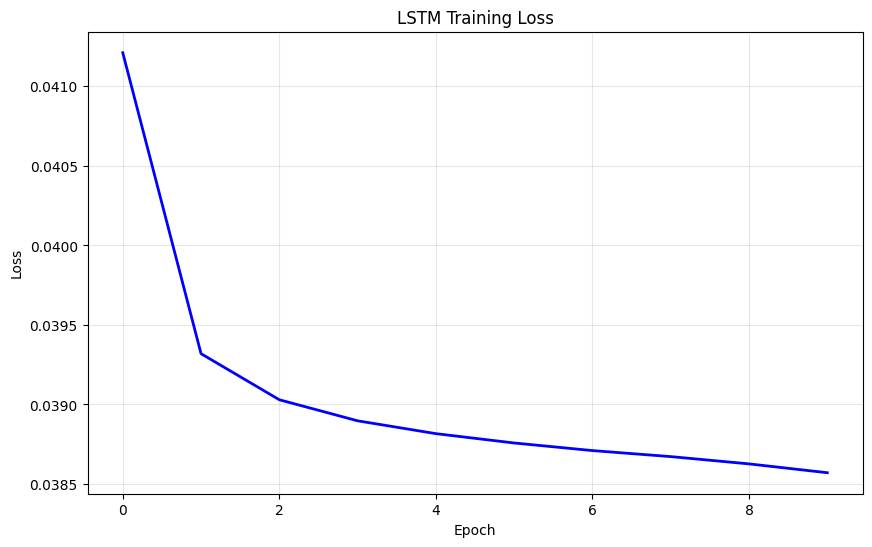

LSTM training completed!


In [18]:
print("Training LSTM Model...")
print("="*50)

# Train LSTM
lstm_loss_history = train_model(lstm_model, train_loader, num_epochs=10, learning_rate=0.001)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(lstm_loss_history, 'b-', linewidth=2)
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

print("LSTM training completed!")

Training GRU Model...
Epoch [1/10], Loss: 0.040094
Epoch [2/10], Loss: 0.038979
Epoch [3/10], Loss: 0.038845
Epoch [4/10], Loss: 0.038766
Epoch [5/10], Loss: 0.038699
Epoch [6/10], Loss: 0.038622
Epoch [7/10], Loss: 0.038524
Epoch [8/10], Loss: 0.038403
Epoch [9/10], Loss: 0.038291
Epoch [10/10], Loss: 0.038173


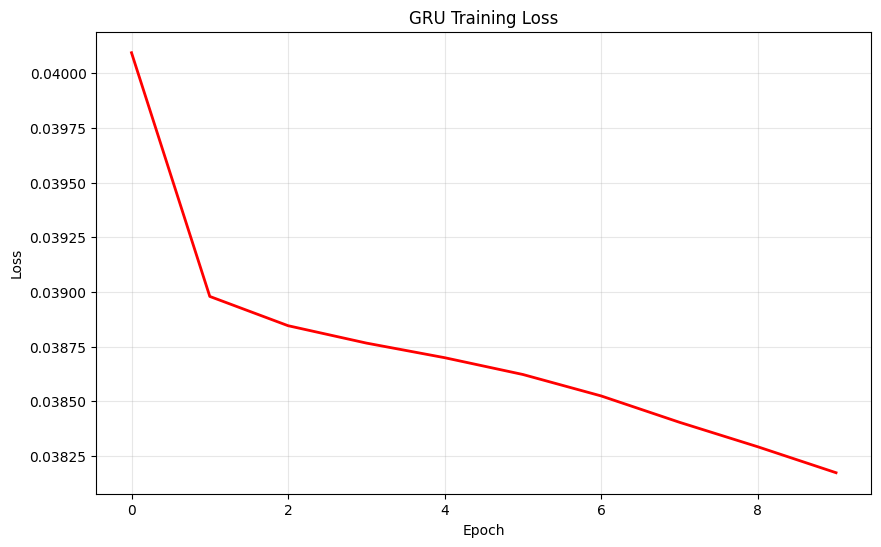

GRU training completed!


In [19]:
print("Training GRU Model...")
print("="*50)

# Train GRU
gru_loss_history = train_model(gru_model, train_loader, num_epochs=10, learning_rate=0.001)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(gru_loss_history, 'r-', linewidth=2)
plt.title('GRU Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

print("GRU training completed!")


## Train Transformer Model
Description: Train the Transformer model and track training progress

Training Transformer Model...
Epoch [1/5], Loss: 0.043031
Epoch [2/5], Loss: 0.039809
Epoch [3/5], Loss: 0.039556
Epoch [4/5], Loss: 0.039421
Epoch [5/5], Loss: 0.039323


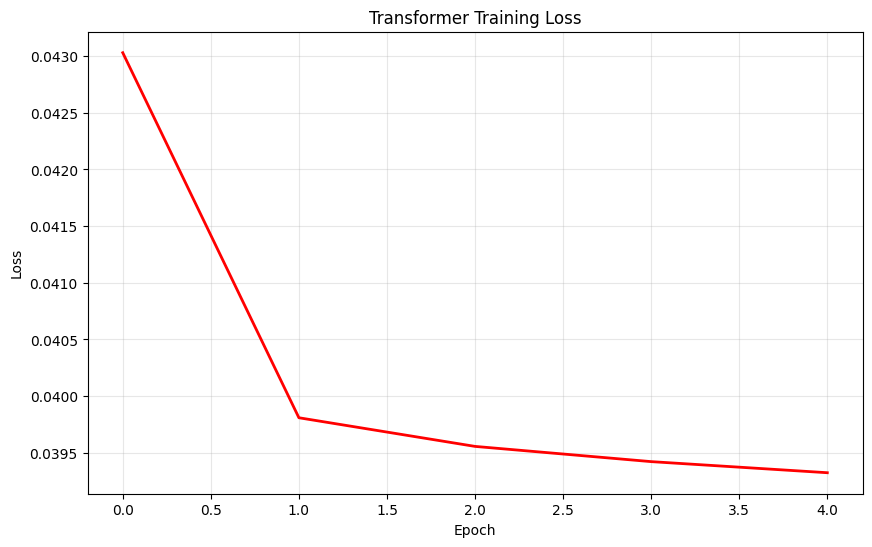

Transformer training completed!


In [20]:
print("Training Transformer Model...")
print("="*50)

# Train Transformer
transformer_loss_history = train_model(transformer_model, train_loader, num_epochs=5, learning_rate=0.001)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(transformer_loss_history, 'r-', linewidth=2)
plt.title('Transformer Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

print("Transformer training completed!")


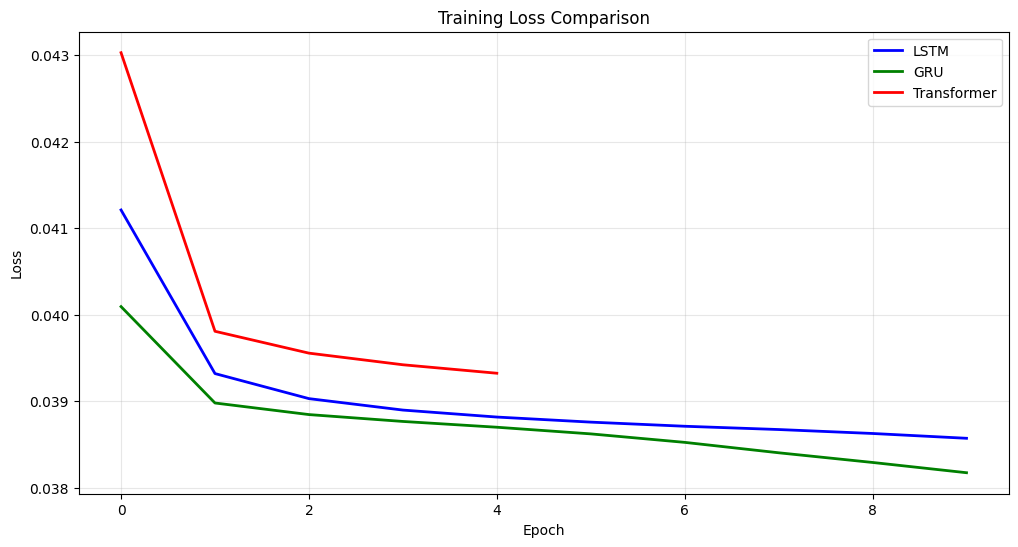

In [21]:
# Compare training curves
plt.figure(figsize=(12, 6))
plt.plot(lstm_loss_history, 'b-', label='LSTM', linewidth=2)
plt.plot(gru_loss_history, 'g-', label='GRU', linewidth=2)           # added GRU
plt.plot(transformer_loss_history, 'r-', label='Transformer', linewidth=2)
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Evaluate Models

Evaluating LSTM Model...
LSTM Results:
MAE: 1858.3461
RMSE: 3733.9804
MAPE: 4.88%

LSTM Prediction Samples:


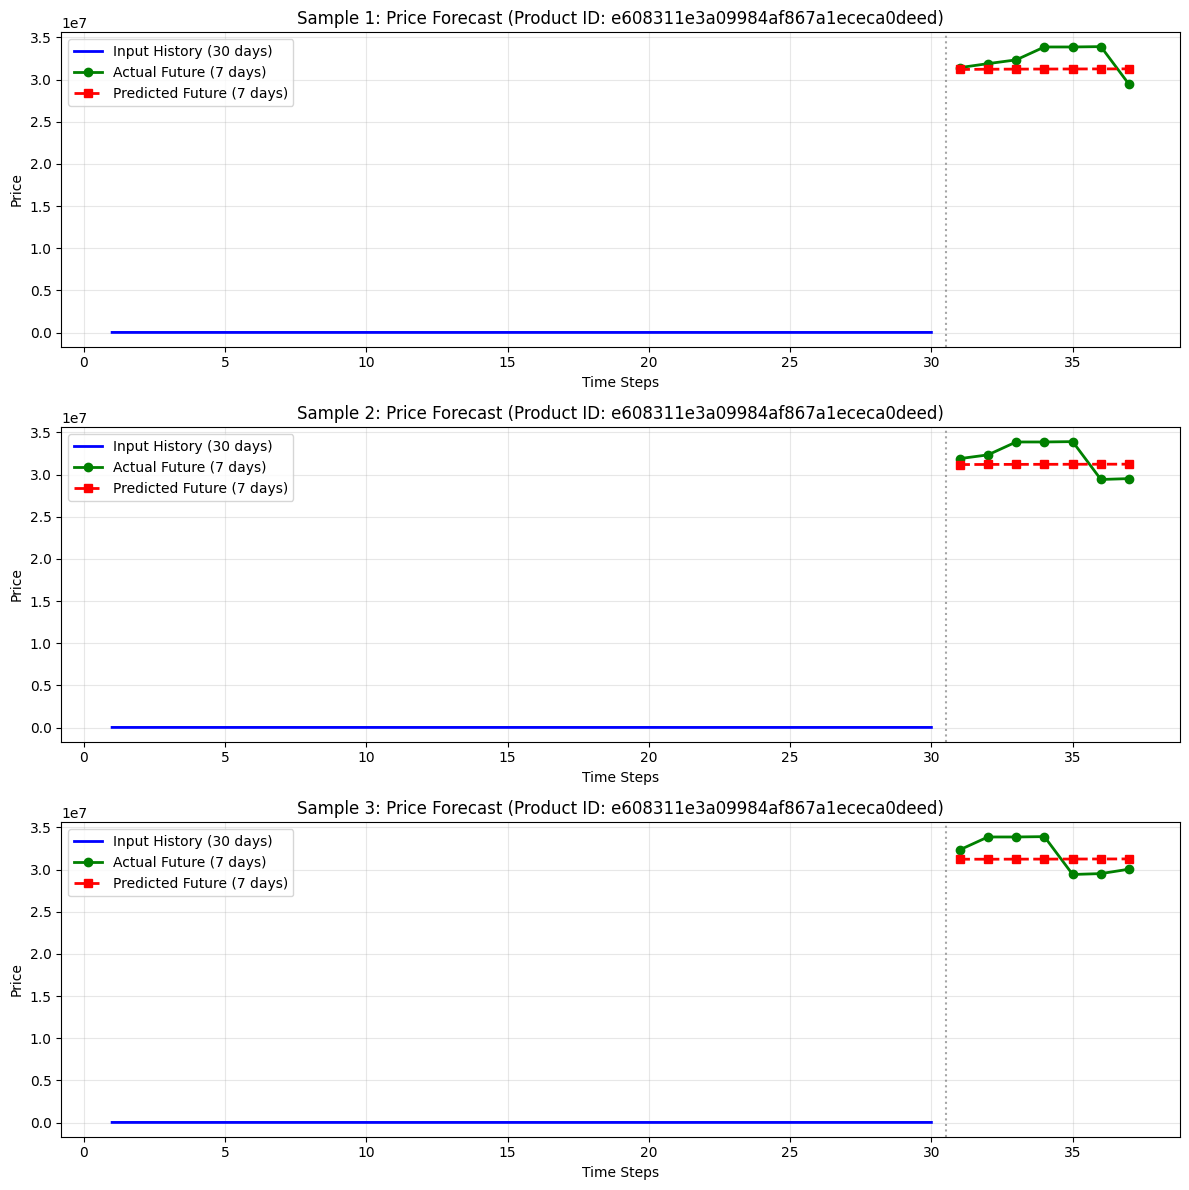

In [22]:
print("Evaluating LSTM Model...")
print("="*40)

# Evaluate LSTM
lstm_mae, lstm_rmse, lstm_mape, lstm_pred, lstm_actual = evaluate_model(
    lstm_model, test_loader, scalers, product_indices_test
)

print(f"LSTM Results:")
print(f"MAE: {lstm_mae:.4f}")
print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAPE: {lstm_mape:.2f}%")  # added MAPE

# Plot LSTM predictions with proper input/output separation
print("\nLSTM Prediction Samples:")
plot_predictions(X_test, lstm_actual, lstm_pred, scalers, product_indices_test, num_samples=3)


Evaluating GRU Model...
GRU Results:
MAE: 1867.5983
RMSE: 3760.3122
MAPE: 4.89%

GRU Prediction Samples:


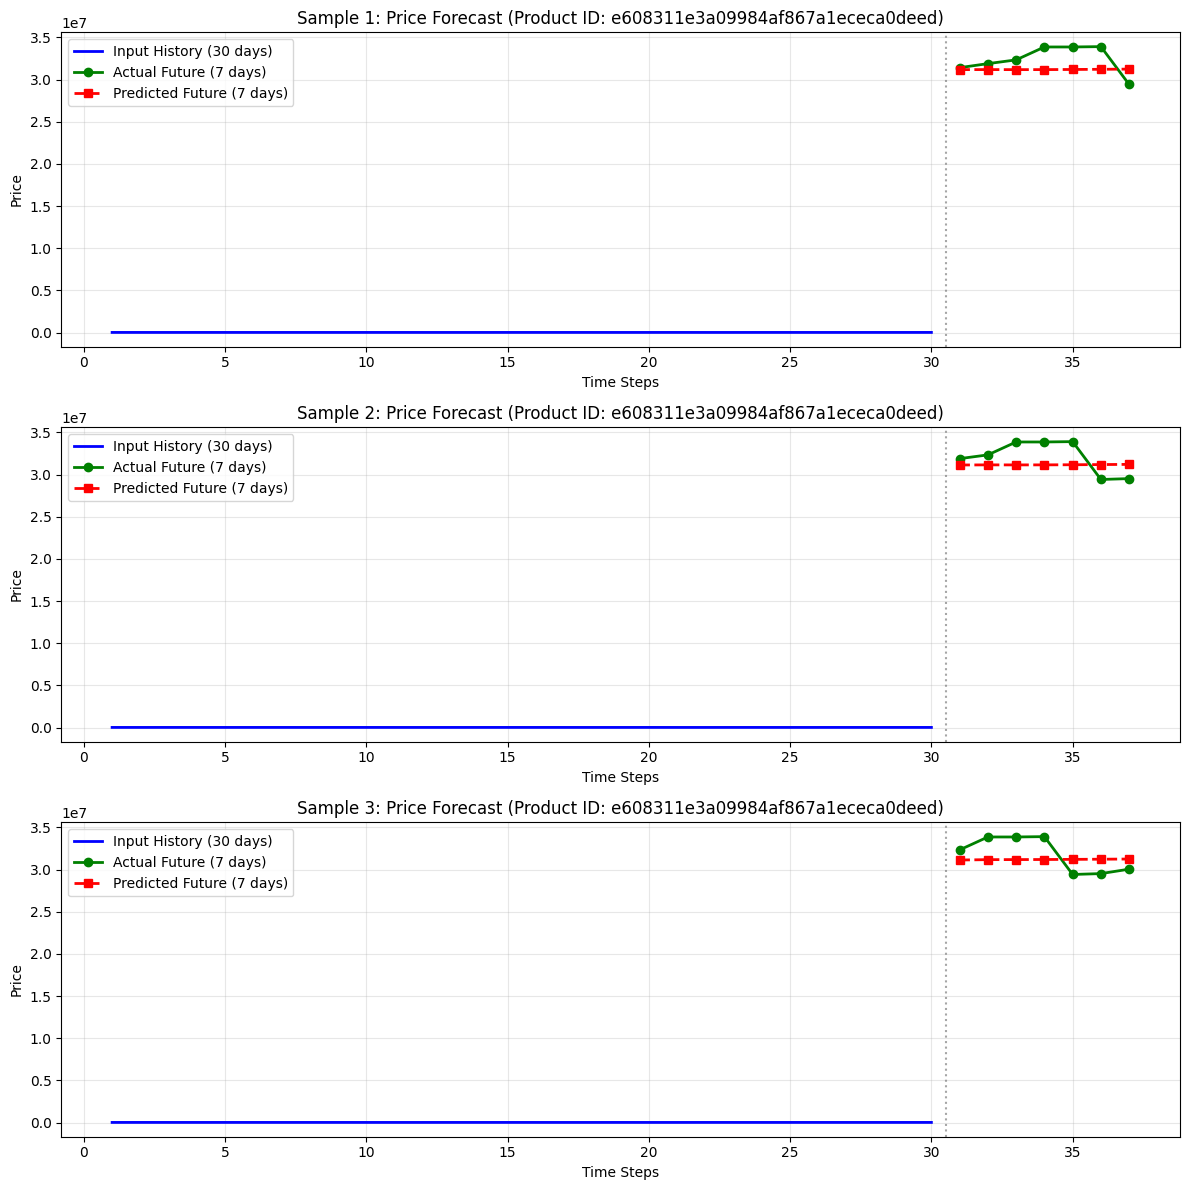

In [23]:
print("Evaluating GRU Model...")
print("="*40)

# Evaluate GRU
gru_mae, gru_rmse, gru_mape, gru_pred, gru_actual = evaluate_model(
    gru_model, test_loader, scalers, product_indices_test
)

print(f"GRU Results:")
print(f"MAE: {gru_mae:.4f}")
print(f"RMSE: {gru_rmse:.4f}")
print(f"MAPE: {gru_mape:.2f}%")  # added MAPE

# Plot GRU predictions with proper input/output separation
print("\nGRU Prediction Samples:")
plot_predictions(X_test, gru_actual, gru_pred, scalers, product_indices_test, num_samples=3)


Evaluating Transformer Model...
Transformer Results:
MAE: 1866.2349
RMSE: 3732.5503
MAPE: 4.97%

Transformer Prediction Samples:


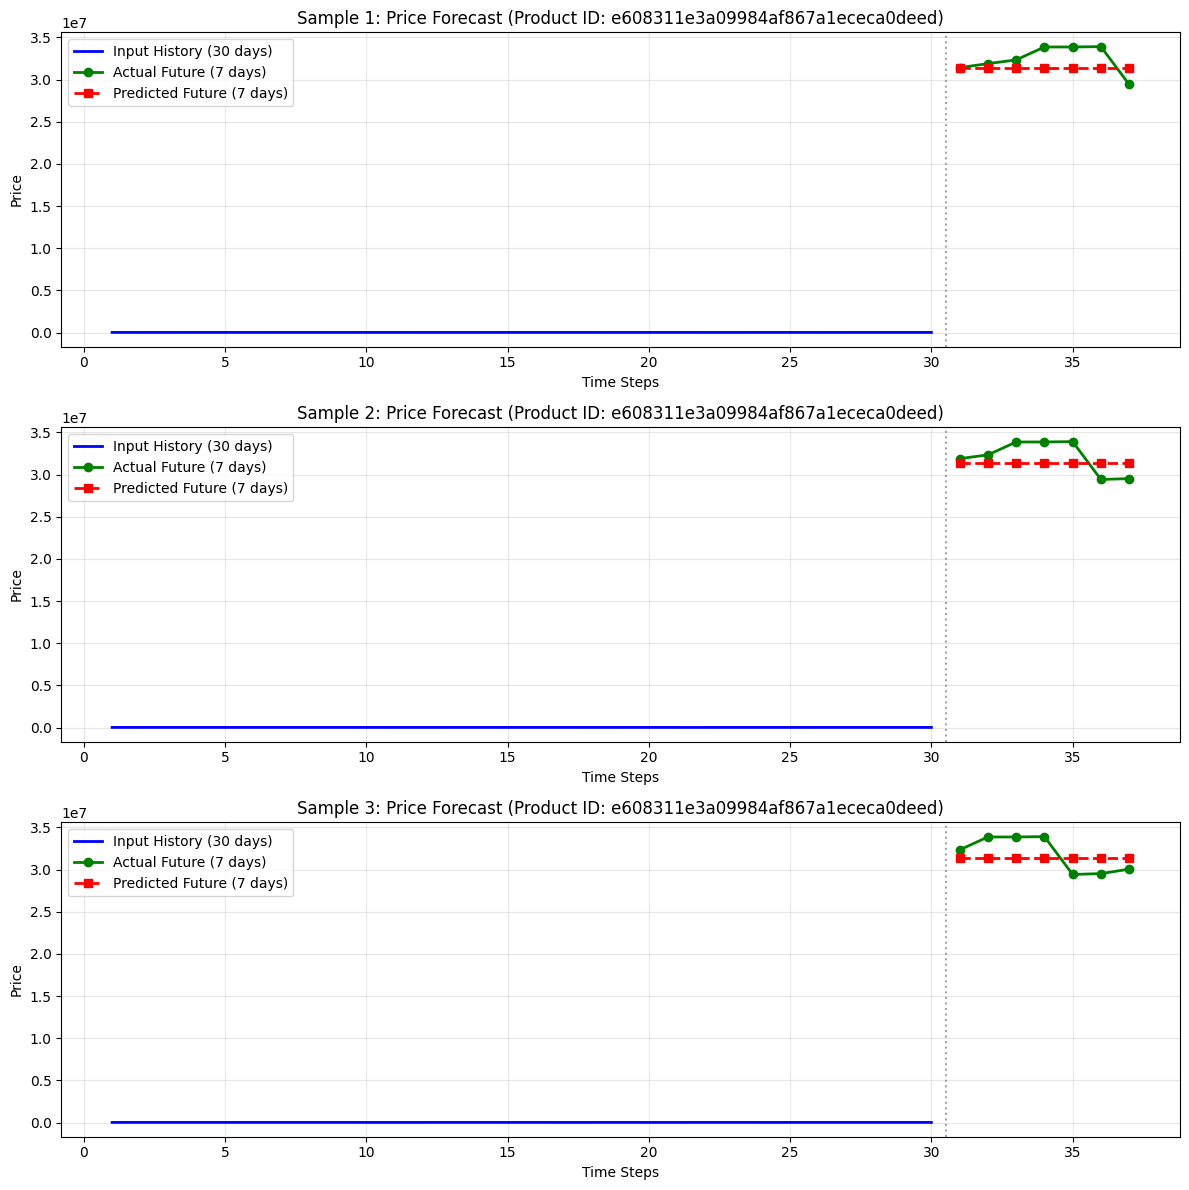

In [24]:
print("Evaluating Transformer Model...")
print("="*40)

# Evaluate Transformer
transformer_mae, transformer_rmse, transformer_mape, transformer_pred, transformer_actual = evaluate_model(
    transformer_model, test_loader, scalers, product_indices_test
)

print(f"Transformer Results:")
print(f"MAE: {transformer_mae:.4f}")
print(f"RMSE: {transformer_rmse:.4f}")
print(f"MAPE: {transformer_mape:.2f}%")  # added MAPE

# Plot Transformer predictions with proper input/output separation
print("\nTransformer Prediction Samples:")
plot_predictions(X_test, transformer_actual, transformer_pred, scalers, product_indices_test, num_samples=3)


FINAL MODEL COMPARISON
      Model         MAE  MAE (%)        RMSE  MAPE (%)
       LSTM 1858.346069 4.992152 3733.980450  4.877553
        GRU 1867.598267 5.017006 3760.312221  4.891636
Transformer 1866.234863 5.013344 3732.550335  4.969635

🏆 LSTM model performs best (lowest MAE)


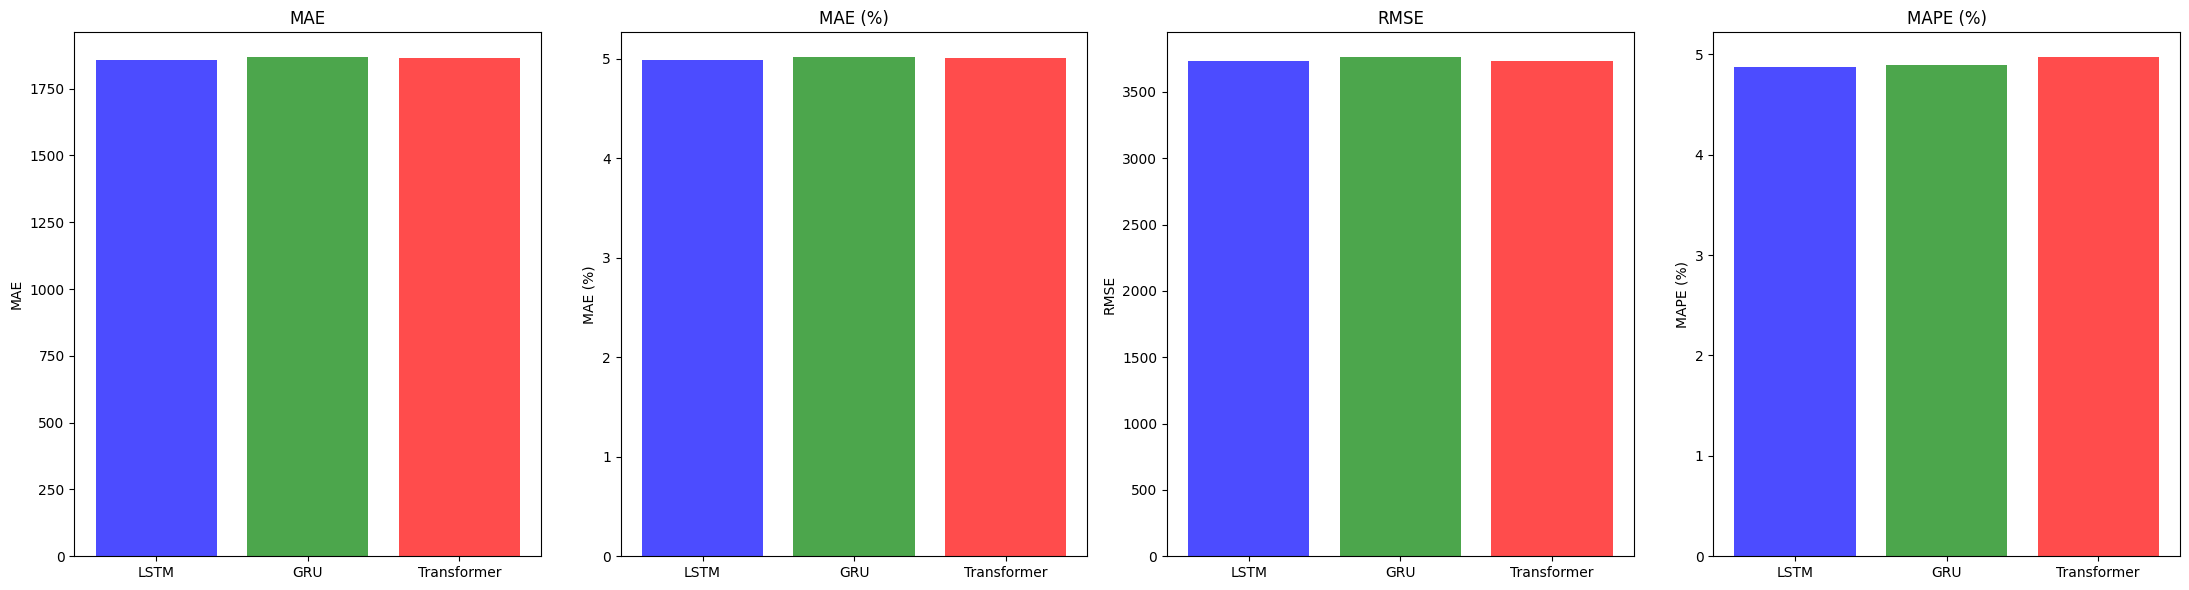

In [25]:
print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

# Calculate MAE % for each model
lstm_mae_pct = (lstm_mae / np.mean(lstm_actual)) * 100
gru_mae_pct = (gru_mae / np.mean(gru_actual)) * 100
transformer_mae_pct = (transformer_mae / np.mean(transformer_actual)) * 100

# Create DataFrame including MAE %, MAPE
results_df = pd.DataFrame({
    'Model': ['LSTM', 'GRU', 'Transformer'],
    'MAE': [lstm_mae, gru_mae, transformer_mae],
    'MAE (%)': [lstm_mae_pct, gru_mae_pct, transformer_mae_pct],  # added MAE %
    'RMSE': [lstm_rmse, gru_rmse, transformer_rmse],
    'MAPE (%)': [lstm_mape, gru_mape, transformer_mape]           # already MAPE
})

print(results_df.to_string(index=False))
print()

# Determine best model (by MAE)
best_model = results_df.loc[results_df['MAE'].idxmin(), 'Model']
print(f"🏆 {best_model} model performs best (lowest MAE)")

# Create comparison plots
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

models = results_df['Model'].tolist()
maes = results_df['MAE'].tolist()
mae_pcts = results_df['MAE (%)'].tolist()
rmses = results_df['RMSE'].tolist()
mapes = results_df['MAPE (%)'].tolist()

axes[0].bar(models, maes, color=['blue', 'green', 'red'], alpha=0.7)
axes[0].set_title('MAE')
axes[0].set_ylabel('MAE')

axes[1].bar(models, mae_pcts, color=['blue', 'green', 'red'], alpha=0.7)
axes[1].set_title('MAE (%)')
axes[1].set_ylabel('MAE (%)')

axes[2].bar(models, rmses, color=['blue', 'green', 'red'], alpha=0.7)
axes[2].set_title('RMSE')
axes[2].set_ylabel('RMSE')

axes[3].bar(models, mapes, color=['blue', 'green', 'red'], alpha=0.7)
axes[3].set_title('MAPE (%)')
axes[3].set_ylabel('MAPE (%)')

plt.tight_layout()
plt.show()


In [26]:
# Save models
torch.save(lstm_model.state_dict(), 'lstm_forecaster.pth')
torch.save(gru_model.state_dict(), 'gru_forecaster.pth')           # added GRU
torch.save(transformer_model.state_dict(), 'transformer_forecaster.pth')

# Save all product scalers
with open('product_scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print("Models and scalers saved successfully!")
print("Files created:")
print("- lstm_forecaster.pth")
print("- gru_forecaster.pth")                                    # added GRU
print("- transformer_forecaster.pth")
print(f"- product_scalers.pkl (contains {len(scalers)} individual scalers)")


Models and scalers saved successfully!
Files created:
- lstm_forecaster.pth
- gru_forecaster.pth
- transformer_forecaster.pth
- product_scalers.pkl (contains 869 individual scalers)


In [27]:

# Example of how to load and use saved models
def load_models():
    """Load saved models and scaler"""

    # Load scaler
    with open('product_scalers.pkl', 'rb') as f:  # updated to your saved scalers file
        loaded_scalers = pickle.load(f)

    # Load LSTM model
    loaded_lstm = LSTMSeq2Seq().to(device)
    loaded_lstm.load_state_dict(torch.load('lstm_forecaster.pth'))
    loaded_lstm.eval()

    # Load GRU model
    loaded_gru = GRUSeq2Seq().to(device)
    loaded_gru.load_state_dict(torch.load('gru_forecaster.pth'))
    loaded_gru.eval()

    # Load Transformer model
    loaded_transformer = TransformerSeq2Seq().to(device)
    loaded_transformer.load_state_dict(torch.load('transformer_forecaster.pth'))
    loaded_transformer.eval()

    return loaded_lstm, loaded_gru, loaded_transformer, loaded_scalers

print("Model loading function defined.")
print("Use load_models() to reload saved models for inference.")


Model loading function defined.
Use load_models() to reload saved models for inference.
